#  Credit Card Fraud Detection

This project demonstrates a robust approach to detecting fraudulent credit card transactions using Python and machine learning.  

As a Data Analyst with 6 years of experience, this notebook emphasizes my skills in
data preprocessing, handling highly imbalanced datasets, and building interpretable models.

In [1]:
# ============================
# 1. Imports & Loading Data
# ============================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

# Machine Learning Libraries
from sklearn.preprocessing import RobustScaler
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

# Display all columns
pd.set_option('display.max_columns', None)

# Load dataset
df = pd.read_csv(r"C:\Users\Badri Reddy\Desktop\creditcard.csv", low_memory=False)
print("Dataset Shape:", df.shape)
df.head()


Dataset Shape: (284807, 31)


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,V15,V16,V17,V18,V19,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,0.090794,-0.551600,-0.617801,-0.991390,-0.311169,1.468177,-0.470401,0.207971,0.025791,0.403993,0.251412,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,-0.166974,1.612727,1.065235,0.489095,-0.143772,0.635558,0.463917,-0.114805,-0.183361,-0.145783,-0.069083,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,0.207643,0.624501,0.066084,0.717293,-0.165946,2.345865,-2.890083,1.109969,-0.121359,-2.261857,0.524980,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,-0.054952,-0.226487,0.178228,0.507757,-0.287924,-0.631418,-1.059647,-0.684093,1.965775,-1.232622,-0.208038,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,0.753074,-0.822843,0.538196,1.345852,-1.119670,0.175121,-0.451449,-0.237033,-0.038195,0.803487,0.408542,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


# Exploratory Data Analysis (EDA)
Check class imbalance and visualize distribution.

Fraudulent Transactions: 492
Non-Fraudulent Transactions: 284315
Percentage of Fraud: 0.173%


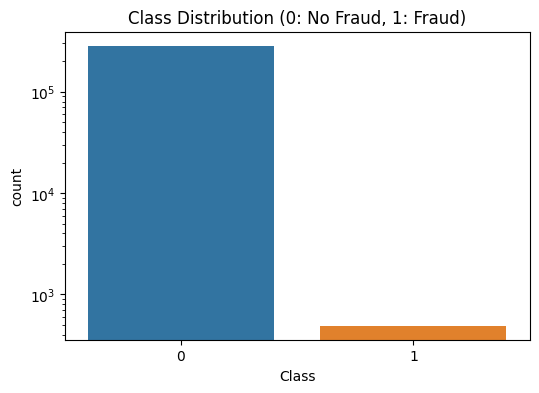

In [2]:
# Class distribution
fraud = df[df['Class'] == 1]
non_fraud = df[df['Class'] == 0]

print(f"Fraudulent Transactions: {len(fraud)}")
print(f"Non-Fraudulent Transactions: {len(non_fraud)}")

imbalance_pct = (len(fraud) / len(df)) * 100
print(f"Percentage of Fraud: {imbalance_pct:.3f}%")

# Visualization
plt.figure(figsize=(6,4))
sns.countplot(x='Class', data=df)
plt.title('Class Distribution (0: No Fraud, 1: Fraud)')
plt.yscale('log')
plt.show()


# Preprocessing & Scaling
Scale 'Amount' and 'Time' using RobustScaler to handle outliers.


In [3]:
rob_scaler = RobustScaler()

df['scaled_amount'] = rob_scaler.fit_transform(df['Amount'].values.reshape(-1,1))
if 'Time' in df.columns:
    df['scaled_time'] = rob_scaler.fit_transform(df['Time'].values.reshape(-1,1))
    df.drop(['Time','Amount'], axis=1, inplace=True)
    # Move scaled columns to front
    scaled_amount = df.pop('scaled_amount')
    scaled_time = df.pop('scaled_time')
    df.insert(0, 'scaled_amount', scaled_amount)
    df.insert(1, 'scaled_time', scaled_time)
else:
    df.drop(['Amount'], axis=1, inplace=True)
    df.insert(0, 'scaled_amount', df.pop('scaled_amount'))

df.head()


,scaled_amount,scaled_time,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,V15,V16,V17,V18,V19,V20,V21,V22,V23,V24,V25,V26,V27,V28,Class
0,1.783274,-0.994983,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,0.090794,-0.551600,-0.617801,-0.991390,-0.311169,1.468177,-0.470401,0.207971,0.025791,0.403993,0.251412,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,0
1,-0.269825,-0.994983,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,-0.166974,1.612727,1.065235,0.489095,-0.143772,0.635558,0.463917,-0.114805,-0.183361,-0.145783,-0.069083,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,0
2,4.983721,-0.994972,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,0.207643,0.624501,0.066084,0.717293,-0.165946,2.345865,-2.890083,1.109969,-0.121359,-2.261857,0.524980,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,0
3,1.418291,-0.994972,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,-0.054952,-0.226487,0.178228,0.507757,-0.287924,-0.631418,-1.059647,-0.684093,1.965775,-1.232622,-0.208038,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,0
4,0.670579,-0.994960,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,0.753074,-0.822843,0.538196,1.345852,-1.119670,0.175121,-0.451449,-0.237033,-0.038195,0.803487,0.408542,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,0


# Train/Test Split & SMOTE Balancing
Split data and balance training set only.


In [4]:
X = df.drop('Class', axis=1)
y = df['Class']

# Train/Test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Original training set distribution:", Counter(y_train))
print("Original testing set distribution:", Counter(y_test))

# Apply SMOTE
sm = SMOTE(random_state=42)
X_train_smote, y_train_smote = sm.fit_resample(X_train, y_train)

print("After SMOTE (balanced training set):", Counter(y_train_smote))
print("Testing set remains imbalanced:", Counter(y_test))


Original training set distribution: Counter({0: 227451, 1: 394})
Original testing set distribution: Counter({0: 56864, 1: 98})
After SMOTE (balanced training set): Counter({0: 227451, 1: 227451})
Testing set remains imbalanced: Counter({0: 56864, 1: 98})


# Random Forest Modeling & Evaluation
Train a Random Forest on balanced data and evaluate on original imbalanced test set.


In [5]:
# Train Random Forest
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train_smote, y_train_smote)

# Predict
y_pred = rf.predict(X_test)

# Metrics
print("Classification Report:\n", classification_report(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
roc_auc = roc_auc_score(y_test, rf.predict_proba(X_test)[:,1])
print("ROC-AUC Score:", roc_auc)


Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.85      0.82      0.83        98

    accuracy                           1.00     56962
   macro avg       0.93      0.91      0.92     56962
weighted avg       1.00      1.00      1.00     56962

Confusion Matrix:
 [[56850    14]
 [   18    80]]
ROC-AUC Score: 0.9738163308373433


# Feature Importance Visualization
Identify which features influence fraud predictions the most.


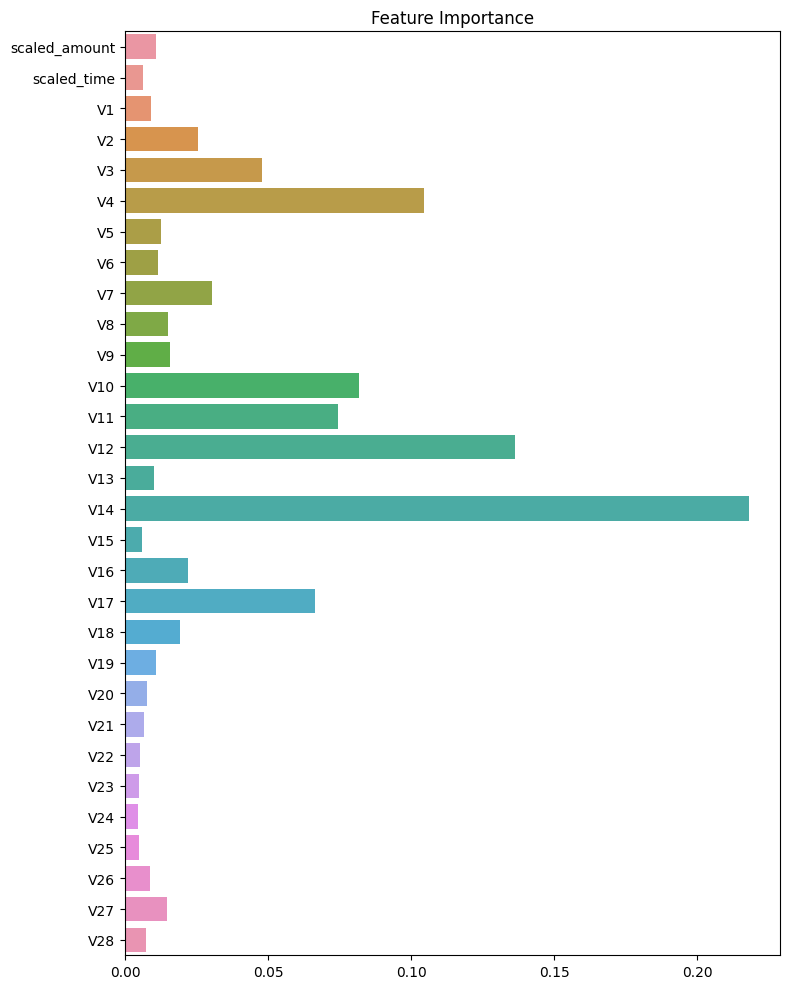

In [6]:
importances = rf.feature_importances_
features = X_train.columns

plt.figure(figsize=(8,10))
sns.barplot(x=importances, y=features)
plt.title("Feature Importance")
plt.tight_layout()
plt.show()


# Summary

- **Data Preprocessing:** Outliers handled using RobustScaler.  
- **Class Imbalance:** Original training set highly skewed; SMOTE applied to balance.  
- **Model:** Random Forest trained on balanced data.  
- **Evaluation:** Test set remains imbalanced to reflect real-world fraud detection. Metrics include precision, recall, F1-score, and ROC-AUC.  
- **Feature Importance:** Highlights which transaction features are most predictive of fraud.
